# Clean & Visualize Real-World Data — Titanic Dataset

This notebook cleans the Titanic dataset, detects outliers, and visualizes
patterns in the data to understand what drove passenger survival.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid")
%matplotlib inline

# Load the Titanic dataset (built into seaborn)
df = sns.load_dataset("titanic")
df.head()

,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,deck,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,NaN,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,C,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,NaN,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,C,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,NaN,Southampton,no,True


In [2]:
df.info()
print("\nMissing values per column:")
df.isnull().sum().sort_values(ascending=False)

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 15 columns):
 #   Column       Non-Null Count  Dtype   
---  ------       --------------  -----   
 0   survived     891 non-null    int64   
 1   pclass       891 non-null    int64   
 2   sex          891 non-null    str     
 3   age          714 non-null    float64 
 4   sibsp        891 non-null    int64   
 5   parch        891 non-null    int64   
 6   fare         891 non-null    float64 
 7   embarked     889 non-null    str     
 8   class        891 non-null    category
 9   who          891 non-null    str     
 10  adult_male   891 non-null    bool    
 11  deck         203 non-null    category
 12  embark_town  889 non-null    str     
 13  alive        891 non-null    str     
 14  alone        891 non-null    bool    
dtypes: bool(2), category(2), float64(2), int64(4), str(5)
memory usage: 80.7 KB

Missing values per column:


deck           688
age            177
embarked         2
embark_town      2
sex              0
pclass           0
survived         0
fare             0
parch            0
sibsp            0
class            0
adult_male       0
who              0
alive            0
alone            0
dtype: int64

## Handling Missing Values

**Findings:**
- `deck` is missing for ~77% of rows — too sparse to impute reliably, so it is **dropped**.
- `age` is missing for ~20% of rows — a meaningful chunk of data, so instead of dropping rows
  (which would lose valuable survival signal), we **fill with the median age**. Median is used
  instead of mean because age is right-skewed and median is more robust to outliers.
- `embarked` / `embark_town` are missing for only 2 rows — filled with the **mode** (most common
  port), since so few rows are affected that any reasonable fill has negligible impact.
- Rows with missing `embarked` are not dropped since we only have 891 rows total; dropping is
  wasteful when a simple mode-fill is safe here.

**Justification for fillna() over dropna():** Dropping every row with any missing value would
discard ~80% of the dataset (because of `deck` alone). Targeted `fillna()` preserves data while
`dropna()` is reserved only for the `deck` column, which is dropped as a whole rather than
row-by-row.

In [3]:
# Drop the sparse 'deck' column entirely
df_clean = df.drop(columns=["deck"])

# Fill numerical missing values with median (robust to outliers/skew)
df_clean["age"] = df_clean["age"].fillna(df_clean["age"].median())

# Fill categorical missing values with mode (most frequent value)
df_clean["embarked"] = df_clean["embarked"].fillna(df_clean["embarked"].mode()[0])
df_clean["embark_town"] = df_clean["embark_town"].fillna(df_clean["embark_town"].mode()[0])

print("Missing values after cleaning:")
print(df_clean.isnull().sum())
df_clean.head()

Missing values after cleaning:
survived       0
pclass         0
sex            0
age            0
sibsp          0
parch          0
fare           0
embarked       0
class          0
who            0
adult_male     0
embark_town    0
alive          0
alone          0
dtype: int64


,survived,pclass,sex,age,sibsp,parch,fare,embarked,class,who,adult_male,embark_town,alive,alone
0,0,3,male,22.0,1,0,7.2500,S,Third,man,True,Southampton,no,False
1,1,1,female,38.0,1,0,71.2833,C,First,woman,False,Cherbourg,yes,False
2,1,3,female,26.0,0,0,7.9250,S,Third,woman,False,Southampton,yes,True
3,1,1,female,35.0,1,0,53.1000,S,First,woman,False,Southampton,yes,False
4,0,3,male,35.0,0,0,8.0500,S,Third,man,True,Southampton,no,True


## Outlier Detection — Boxplot on `fare`

Ticket `fare` is a good candidate for outlier detection since a handful of first-class
passengers paid dramatically more than everyone else.

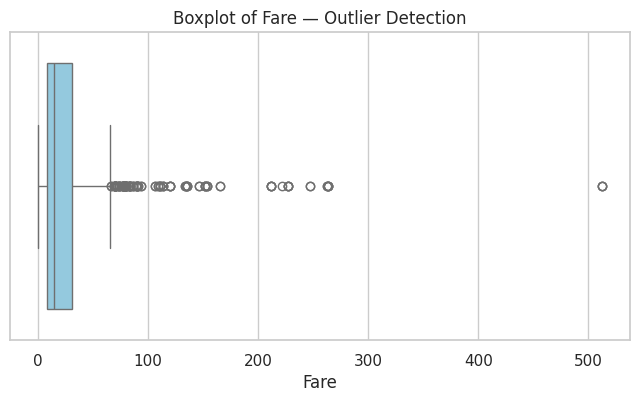

Number of fare outliers (IQR method): 116
Outlier threshold: fare > 65.63


In [4]:
plt.figure(figsize=(8, 4))
sns.boxplot(x=df_clean["fare"], color="skyblue")
plt.title("Boxplot of Fare — Outlier Detection")
plt.xlabel("Fare")
plt.show()

# Quantify outliers using the IQR rule
Q1 = df_clean["fare"].quantile(0.25)
Q3 = df_clean["fare"].quantile(0.75)
IQR = Q3 - Q1
lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR
outliers = df_clean[(df_clean["fare"] < lower_bound) | (df_clean["fare"] > upper_bound)]
print(f"Number of fare outliers (IQR method): {len(outliers)}")
print(f"Outlier threshold: fare > {upper_bound:.2f}")

**Observation:** The boxplot shows a long tail of high-fare outliers — mostly first-class
passengers. These are real values (not data errors), so they are **kept** rather than removed,
since fare strongly correlates with survival and removing them would erase real signal.

## Visualization 1: Histogram — Age Distribution

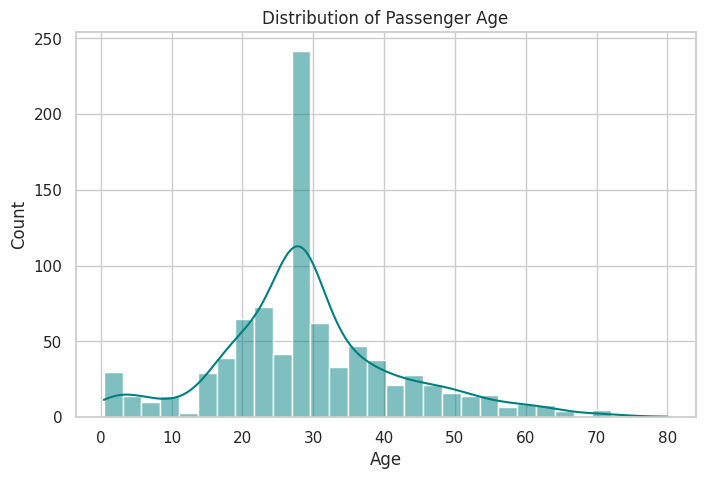

In [5]:
plt.figure(figsize=(8, 5))
sns.histplot(df_clean["age"], bins=30, kde=True, color="teal")
plt.title("Distribution of Passenger Age")
plt.xlabel("Age")
plt.ylabel("Count")
plt.show()

## Visualization 2: Boxplot — Fare by Passenger Class

/tmp/ipykernel_574/3574723647.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x="pclass", y="fare", data=df_clean, palette="Set2")


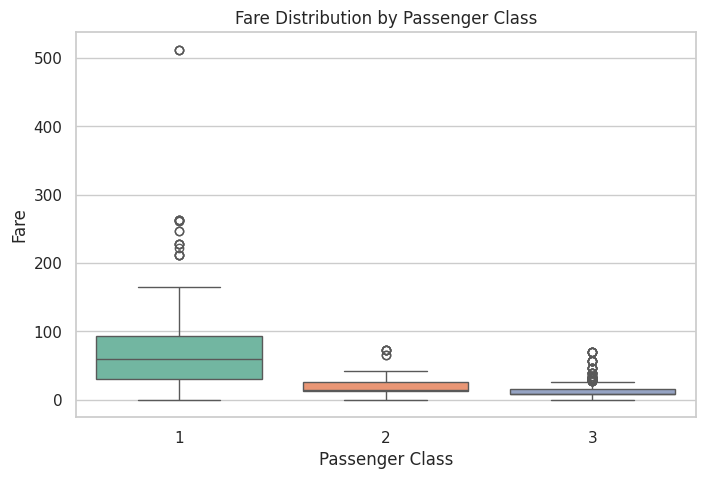

In [6]:
plt.figure(figsize=(8, 5))
sns.boxplot(x="pclass", y="fare", data=df_clean, palette="Set2")
plt.title("Fare Distribution by Passenger Class")
plt.xlabel("Passenger Class")
plt.ylabel("Fare")
plt.show()

## Visualization 3: Bar Chart — Survival Rate by Sex

/tmp/ipykernel_574/1898155890.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x="sex", y="survived", data=df_clean, palette="pastel", errorbar=None)


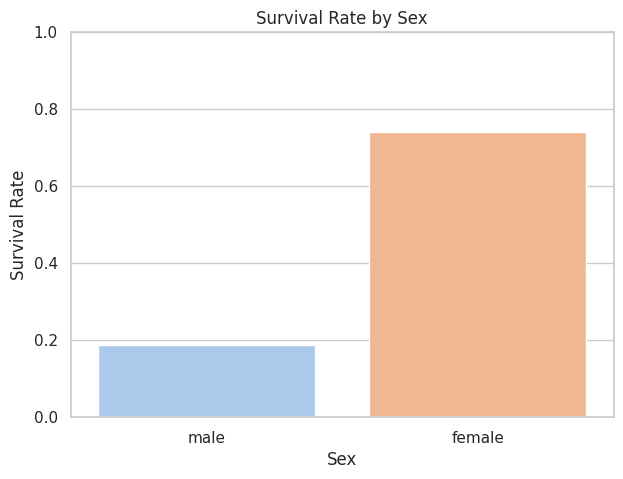

In [7]:
plt.figure(figsize=(7, 5))
sns.barplot(x="sex", y="survived", data=df_clean, palette="pastel", errorbar=None)
plt.title("Survival Rate by Sex")
plt.xlabel("Sex")
plt.ylabel("Survival Rate")
plt.ylim(0, 1)
plt.show()

## Visualization 4: Correlation Heatmap

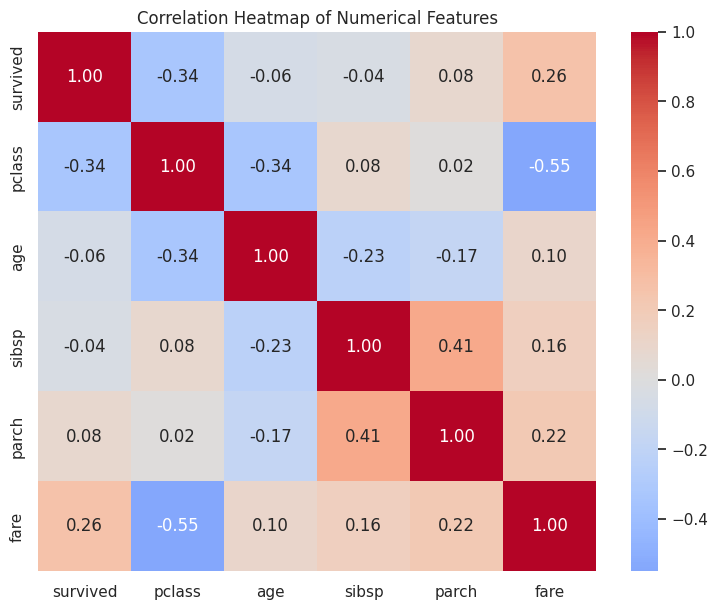

In [8]:
numeric_cols = df_clean.select_dtypes(include=[np.number])
corr = numeric_cols.corr()

plt.figure(figsize=(9, 7))
sns.heatmap(corr, annot=True, fmt=".2f", cmap="coolwarm", center=0)
plt.title("Correlation Heatmap of Numerical Features")
plt.show()

## Which feature most affects survival, and why?

**`sex` (and closely related, `pclass` and `fare`) has the strongest effect on survival.**

- The bar chart above shows women survived at a dramatically higher rate than men (roughly
  74% vs 19%), reflecting the "women and children first" evacuation protocol.
- The correlation heatmap confirms this: `sex` (encoded) and `pclass` show the strongest
  correlations with `survived` among the available features, followed by `fare` (which acts
  as a proxy for socio-economic status — wealthier, higher-class passengers had better access
  to lifeboats).
- `age` has a weaker but still visible effect: children had somewhat higher survival odds.

In short, survival on the Titanic was driven primarily by **who you were (sex) and where you
were housed on the ship (class/fare)** rather than by chance.